In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
from helpers import get_stats, get_imgs, average_stats, printer, showResult
from distortions import distortions, post_process

In [2]:
# Code referenced from:
# https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html

def pre_process(imgBGR, kernel, fg_threshold): # add hyperparameter kernel size and intensity value for foreground

    # Gaussian Filter to remove noise from soil
    imgBGR = cv2.GaussianBlur(imgBGR, (5,5), 0)

    # Threshold against the difference between green and red intensities.
    # Normal greyscale thresholding and HSV brightness thresholding was also attempted, but they had subpar results.
    b, g, r = cv2.split(imgBGR)
    intensity = g.astype(np.int16) - r.astype(np.int16)

    # Normalise and rescale to fit cv2.threshold function
    intensity = cv2.normalize(intensity, None, 0, 255, cv2.NORM_MINMAX)
    intensity = intensity.astype(np.uint8)

    # Otsu thresholding based on G-R intensity values.
    _, thresh = cv2.threshold(intensity, 0, 255, cv2.THRESH_BINARY+ cv2.THRESH_OTSU)

    # Morphological Processing
    K = np.ones((3,3), np.uint8)
    process = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel,iterations = 2)    
    process = cv2.morphologyEx(process,cv2.MORPH_CLOSE,kernel,iterations = 2)
 
    # Obtain foreground by thresholding against G-R intensities at a chosen value    
    _, fg = cv2.threshold(intensity, fg_threshold, 255, cv2.THRESH_BINARY)

    # Obtain background by dilating current threshold.
    bg = cv2.dilate(process, kernel, iterations=3)

    # Remove pixels in both bg and fg
    unknown = cv2.subtract(bg,fg)

    # Setup markers for flooding
    markers=np.zeros(fg.shape, dtype=np.int32)
    markers[bg==0] = 1
    markers[fg==255] = 2
    markers[unknown==255] = 0
        
    return markers

In [3]:
# Dataset Paths
train_path = Path("../EWS-Dataset/train")
validate_path = Path("../EWS-Dataset/validation")
test_path = Path("../EWS-Dataset/test")

In [4]:
# Obtain images and labels from dataset
trn_imgs, trn_labels = get_imgs(train_path)
vld_imgs, vld_labels = get_imgs(validate_path)
tst_imgs, tst_labels = get_imgs(test_path)

# Merge training and validation data as advanced segmentation does not require training
vld_imgs = trn_imgs + vld_imgs
vld_labels = trn_labels + vld_labels

In [5]:
# Validiation testing of kernel and thresholding value for foreground markers
K = [np.ones((3,3), np.uint8), np.ones((5,5), np.uint8), np.ones((7,7), np.uint8)]
fg_thresholds = np.arange(10, 180, 10)
stats = np.zeros((len(K), len(fg_thresholds), 5))

time_start = time.perf_counter()
for i in range(len(K)):
    for j in range(len(fg_thresholds)):
        stat_holder = np.zeros((len(vld_imgs), 5))
        for k in range(len(vld_imgs)):
            img = cv2.imread(vld_imgs[k])
            markers = pre_process(img, K[i], fg_thresholds[j])
            watershed = cv2.watershed(img, markers)

            mask = np.ones_like(markers) * 255
            mask[markers > 1] = 0

            label = cv2.imread(vld_labels[k], cv2.IMREAD_GRAYSCALE)
            _, label = cv2.threshold(label, 127, 255, cv2.THRESH_BINARY)
            acc, recall, precision, IoU, f1 = get_stats(mask, label)
            stat_holder[k, :] = (acc, recall, precision, IoU, f1)
    
        stats[i, j, :] = (np.mean(stat_holder[:,0]), np.mean(stat_holder[:,1]), np.mean(stat_holder[:,2]), np.mean(stat_holder[:,3]), np.mean(stat_holder[:,4]))


time_end = time.perf_counter()

In [6]:
# Results of hyperparameter validation
print("Hyperparameter validation results outcomes")
print(stats)
print(f"Time taken for validation: {time_end - time_start}")

Hyperparameter validation results outcomes
[[[0.23148635 0.98879891 0.22497061 0.22400306 0.32847404]
  [0.23188429 0.98866246 0.22504961 0.22407652 0.32855622]
  [0.23386993 0.98836336 0.22544966 0.22446271 0.32900929]
  [0.24142916 0.9877403  0.22695063 0.22592615 0.33076654]
  [0.26323516 0.98654627 0.23189335 0.23077165 0.33664626]
  [0.3046182  0.98443834 0.24377961 0.24243092 0.35024975]
  [0.37274699 0.98079175 0.2644432  0.26262393 0.37308928]
  [0.46675559 0.97483374 0.29630274 0.29340424 0.40865169]
  [0.56935309 0.96524635 0.34402199 0.33838633 0.4598722 ]
  [0.66111099 0.95229334 0.40219145 0.39150368 0.51792741]
  [0.73600639 0.93325722 0.46876279 0.44877129 0.57647257]
  [0.79095363 0.90863873 0.52748214 0.49315235 0.61996814]
  [0.83319312 0.87647148 0.58347485 0.52858355 0.6557861 ]
  [0.86110391 0.83899855 0.63500004 0.55301047 0.6806893 ]
  [0.8778331  0.79410311 0.67965438 0.5638322  0.69414442]
  [0.88561839 0.746003   0.71378996 0.55957842 0.6930374 ]
  [0.88877315

In [7]:
# From hyperparameter validation, we pick
# K = np.ones((3,3), np.uint8)
# fg_threshold = fg_thresholds[15] = 160
# With Accuracy: 0.8866     
# Recall: 0.74495655 
# Precision: 0.71799871

# Now apply model to test data
images = []
labels = []
masks = []
tst_stats = np.zeros((len(tst_imgs), 5))

time_start = time.perf_counter()
for i in range(len(tst_imgs)):
    img = cv2.imread(tst_imgs[i])
    markers = pre_process(img, K[0], fg_thresholds[15])
    watershed = cv2.watershed(img, markers)
    mask = np.ones_like(markers) * 255
    mask[markers > 1] = 0

    label = cv2.imread(tst_labels[i], cv2.IMREAD_GRAYSCALE)
    _, label = cv2.threshold(label, 127, 255, cv2.THRESH_BINARY)
    acc, recall, precision, IoU, f1 = get_stats(mask, label)
    tst_stats[i, :] = (acc, recall, precision, IoU, f1)

    images.append(img)
    labels.append(label)
    masks.append(mask)

time_end = time.perf_counter()
avg_stats = average_stats(tst_stats)
printer("Average", avg_stats)
print(f"Total test time: {time_end - time_start} seconds")

Average Test Accuracy: 0.8925731292517005
Average Test Recall: 0.7831246290903618
Average Test Precision: 0.761519342560892
Average Test IoU: 0.6364076898970287
Average Test F1 score: 0.753299766335922
Total test time: 0.1646883999928832 seconds


In [8]:
# Apply post-processing
process = []
pro_tst_stats = np.zeros((len(tst_imgs), 5))
for i in range(len(tst_imgs)):
    processed = post_process(masks[i])
    process.append(processed)
    acc, recall, precision, IoU, f1 = get_stats(processed, labels[i])
    pro_tst_stats[i, :] = (acc, recall, precision, IoU, f1)

pro_stats_avg = average_stats(pro_tst_stats)
printer("Average Post-Processed", pro_stats_avg)

Average Post-Processed Test Accuracy: 0.8931040816326531
Average Post-Processed Test Recall: 0.7576729157118587
Average Post-Processed Test Precision: 0.7690162533467664
Average Post-Processed Test IoU: 0.6246992930570147
Average Post-Processed Test F1 score: 0.7430025833535047


Accuracy: 0.6898367346938775
Recall: 0.5693501454898157
Precision: 0.030667955382565764
IoU: 0.029972682478490643
f1 score: 0.05820092705054161


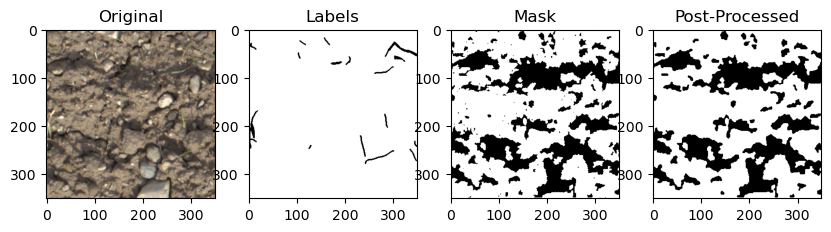

In [9]:
# Worst Case Scenario:
print(f"Accuracy: {tst_stats[np.argmin(tst_stats[:,3]), 0]}")
print(f"Recall: {tst_stats[np.argmin(tst_stats[:,3]), 1]}")
print(f"Precision: {tst_stats[np.argmin(tst_stats[:,3]), 2]}")
print(f"IoU: {tst_stats[np.argmin(tst_stats[:,3]), 3]}")
print(f"f1 score: {tst_stats[np.argmin(tst_stats[:,3]), 4]}")
showResult(np.argmin(tst_stats[:, 3]), images, labels, masks, process)

Accuracy: 0.9124163265306122
Recall: 0.9007211093990755
Precision: 0.9646846038074618
IoU: 0.8719689737470167
f1 score: 0.9316062242224502


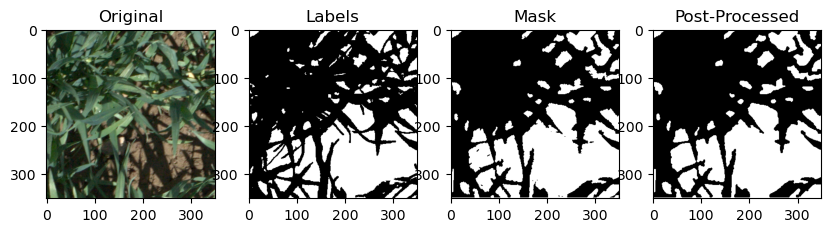

In [10]:
# Best Case Scenario:
print(f"Accuracy: {tst_stats[np.argmax(tst_stats[:,3]), 0]}")
print(f"Recall: {tst_stats[np.argmax(tst_stats[:,3]), 1]}")
print(f"Precision: {tst_stats[np.argmax(tst_stats[:,3]), 2]}")
print(f"IoU: {tst_stats[np.argmax(tst_stats[:,3]), 3]}")
print(f"f1 score: {tst_stats[np.argmax(tst_stats[:,3]), 4]}")
showResult(np.argmax(tst_stats[:, 3]), images, labels, masks, process)

In [11]:
# Apply distortions to test set and determine outcomes.
transform = distortions()
aug_imgs = []
aug_labels = []
for i in range(len(tst_imgs)):
    transformed = transform(image=images[i], mask=labels[i])
    aug_imgs.append(transformed["image"])
    aug_labels.append(transformed["mask"])

In [12]:
# Test on distorted data
aug_masks = []
aug_tst_stats = np.zeros((len(tst_imgs), 5))

time_start = time.perf_counter()
for i in range(len(aug_imgs)):
    markers = pre_process(aug_imgs[i], K[0], fg_thresholds[15])
    watershed = cv2.watershed(aug_imgs[i], markers)
    mask = np.ones_like(markers) * 255
    mask[markers > 1] = 0

    # _, aug_labels[i] = cv2.threshold(aug_labels[i], 127, 255, cv2.THRESH_BINARY)
    acc, recall, precision, IoU, f1 = get_stats(mask, aug_labels[i])
    aug_tst_stats[i, :] = (acc, recall, precision, IoU, f1)

    aug_masks.append(mask)

time_end = time.perf_counter()
aug_avg_stats = average_stats(aug_tst_stats)
printer("Distorted", aug_avg_stats)
print(f"Total test time: {time_end - time_start} seconds")

Distorted Test Accuracy: 0.7759404761904761
Distorted Test Recall: 0.6183652956142006
Distorted Test Precision: 0.6490609063549123
Distorted Test IoU: 0.4268870706690934
Distorted Test F1 score: 0.5667456692331349
Total test time: 0.09630249999463558 seconds


In [13]:
# Apply post-processing
aug_process = []
aug_pro_tst_stats = np.zeros((len(tst_imgs), 5))
for i in range(len(tst_imgs)):
    processed = post_process(aug_masks[i])
    aug_process.append(processed)
    acc, recall, precision, IoU, f1 = get_stats(processed, aug_labels[i])
    aug_pro_tst_stats[i, :] = (acc, recall, precision, IoU, f1)

aug_pro_stats_avg = average_stats(aug_pro_tst_stats)
printer("Average Post-Processed Distorted", aug_pro_stats_avg)

Average Post-Processed Distorted Test Accuracy: 0.7832948979591837
Average Post-Processed Distorted Test Recall: 0.5713266731246365
Average Post-Processed Distorted Test Precision: 0.6825437181292311
Average Post-Processed Distorted Test IoU: 0.41278060378835174
Average Post-Processed Distorted Test F1 score: 0.5547187197555183


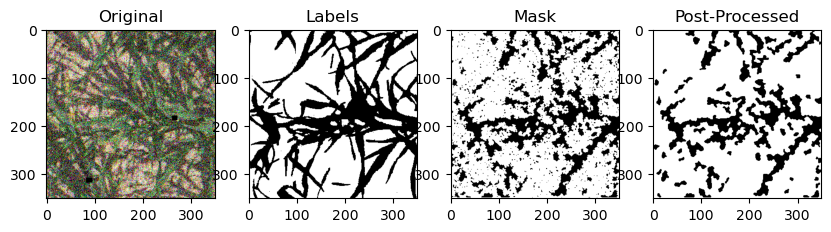

In [14]:
showResult(3, aug_imgs, aug_labels, aug_masks, aug_process)

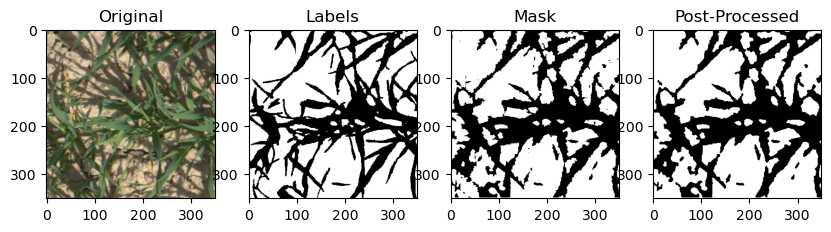

In [15]:
showResult(3, images, labels, masks, process)

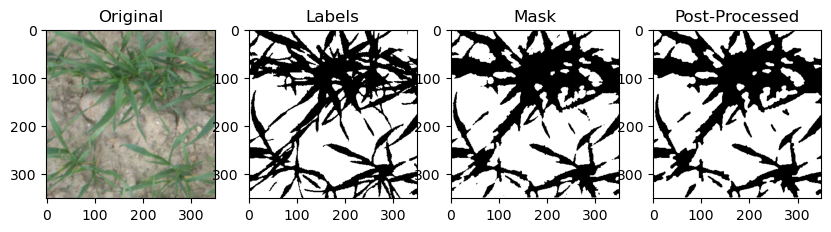

In [16]:
showResult(np.argmax(aug_tst_stats[:, 3]), aug_imgs, aug_labels, aug_masks, aug_process)

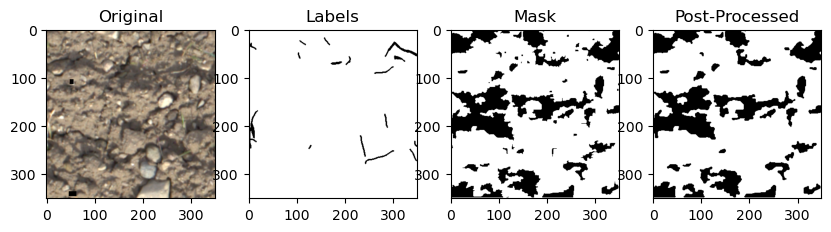

In [18]:
showResult(np.argmin(aug_tst_stats[:, 3]), aug_imgs, aug_labels, aug_masks, aug_process)